<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_9_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El modelo de **Izhikevich**

## **Ejercicio 1)** Importando librerías

**1)** Importe las librerías `numpy` para operar con arrays, `scipy` para utilizar rutinas de algebra lineal y `matplotlib.pyplot` para graficar.

**2)** Suba el archivo "libreria" `ode.py` que fabricó en el práctico 4), e impórtelo.

In [ ]:
# 1.1)
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import matplotlib.pyplot as plt

In [ ]:
# 1.2)
#import ode

def euler(f,x,t,h,p):
    """
    Calcula un paso de integración del método de Euler.

    Argumentos de entrada:

        f : R^n,R -> R^n
        x = x(t) : R^n
        t = tiempo : R
        h = paso de tiempo : R
        p = parametros : R^q

    Retorna aproximacion numérica de

        x(t+h) : R^n

    según el método de Euler.

    # Ejemplos:
    """
    return x+h*f(x,t,p)

def rk4(f,x,t,h,p):
    """
    Calcula un paso de integración del método de Runge Kutta orden 4.

    Argumentos de entrada:

        f : R^n -> R^n
        x = x(t) : R^n
        t = tiempo : R
        h = paso de tiempo : R
        p = parametros : R^q

    Retorna aproximacion numérica de

        x(t+h) : R^n

    según el método de Runge-Kutta de orden 4.

    # Ejemplos:
    """
    k1 = f(x,t,p)
    k2 = f(x+0.5*h*k1,t+0.5*h,p)
    k3 = f(x+0.5*h*k2,t+0.5*h,p)
    k4 = f(x+h*k3,t+h,p)
    return x+h*(k1+2.0*k2+2.0*k3+k4)/6.0

def integrador_ode(m,f,xa,a,b,k,p,c=lambda x,t,p:x):
    """
    Integra numéricamente la ODE

        dx/dt = f(x,t)

    sobre el intervalo t:[a,b] usando k pasos de integración y el método m, bajo condicion inicial x(a)=x0.
    No es necesario que a<b.

    Argumentos de entrada:

        m = metodo de integracion (ej. euler, rk2, etc.)
        f : R^n -> R^n
        xa = condicion inicial : R
        a = tiempo inicial : R
        b = tiempo final : R
        k = num. pasos de integracion : N
        p = parametros : R^q
        c = función condicionante : R^n,R,p -> R^n

    Retorna:

        t : R^{k+1} , t_j = a+j*h para j=0,1,...,k
        w : R^{n,k+1} , w_ij = x_i(t_j) para i=0,1,...,n-1 y j=0,1,...,k

    donde a+k*dt = b.
    """
    assert k>0
    n = len(xa)
    h = (b-a)/k
    w = np.zeros((n,k+1)) # Produce un array con forma y tipo especificada con los parametros,
                          # lleno de ceros. la forma puede ser espcificada con un entero o tupla (n,k+1)
    t = np.zeros(k+1)
    w[:,0] = xa           # actualiza la posicion inicial (columna de indice 0) de las variables con los valores
                          # de las condiciones iniciales
    t[0] = a              # actualiza la posicion cero con el valor del tiempo inicial

    for j in range(k):    #Aca se produce la iteración en j

        t[j+1] = t[j] + h                # iteracion tiempo
        w[:,j+1] = m(f,w[:,j],t[j],h,p)  # iteracion de w
        w[:,j+1] = c(w[:,j+1],t[j+1],p)  # condicion sobre w

    return t,w

## **Ejercicio 2)** Modelo de Izhikevich

El modelo de Izhikevich (ref. 1.) es una simplificación del conocido modelo que Hodgkin y Huxley introdujeron en 1952 (ref. 2. y premio Nobel en Fisiología y Medicina de 1963) para describir el comportamiento del potencial de disparo de una neurona.

El modelo de Izhikevich se describe en términos de la siguiente ODE bidimensional y de primer orden

\begin{eqnarray}
v'(t) &=& gv^2(t) + qv(t) + w - u(t) + I(t) \\
u'(t) &=& a(bv(t)-u(t))
\end{eqnarray}

unida a la siguiente condición de *reseteo*

\begin{eqnarray}
v(t) &\leftarrow& c \\
u(t) &\leftarrow& u(t) + d \\
\end{eqnarray}

la cuál se impone cuando la condición $v(t)\geq s$ se cumple.

En todas estas ecuaciones, $a$, $b$, $c$, $d$, $g$, $q$, $w$ y $s$ son parámetros del modelo.

Además, se considera la función dependiente del tiempo $I:\mathbb{R}\ni t\to I(t)\in \mathbb{R}$, la cual representa una corriente de entrada que exita a la neurona.

Referencias:

1. Eugene M. Izhikevich, Simple Model of Spiking Neurons, IEEE TRANSACTIONS ON NEURAL NETWORKS, VOL. 14, NO. 6, P. 1569, NOVEMBER 2003
2. https://en.wikipedia.org/wiki/Hodgkin%E2%80%93Huxley_model

**1)** Integre el modelo de Izhikevich usando el método RK4 en el intérvalo de tiempo

* $t\in [0,10]$

Considere, para ello, la siguiente elección de valores de los parámetros

* $g=0.04$

* $q=5$

* $w=150$

* $a=0.02$

* $b=0.2$

* $c=-65$

* $d=2$

* $s=30$

una corriente de entrada

\begin{eqnarray}
I(t)
&=&
\left\{
\begin{array}{ll}
0  & t < 10 \\
10 & c.c.
\end{array}
\right.
\end{eqnarray}

y la condición inicial

* $v(0) = -70$

* $u(0) = bv(0)$

Además, utilice el paso de integración

$h=0.1$

**2)** Grafique la solución.

**3)** Reproduzca, aproximadamente, los últimos 8 paneles de la figura 2 del paper en la referencia 1.

Para ello, tenga en cuenta la siguiente tabla confeccionada a partir de la información en la figura 2 del paper

$$
\begin{aligned}
& \text {Tabla 1. Parmaterización por caso. }\\
&\begin{array}{ccccc}
\hline \hline
\text { Caso } & a & b & c & d & I \\
\hline
\text { RS }  & 0.02 & 0.2  & -65 & 8    & I_1 \\
\text { IB }  & 0.02 & 0.2  & -55 & 4    & I_1 \\
\text { CH }  & 0.02 & 0.2  & -50 & 2    & I_1 \\
\text { FS }  & 0.1  & 0.2  & -65 & 2    & I_1 \\
\text { TC1 } & 0.02 & 0.25 & -65 & 0.05 & I_2 \\
\text { TC2 } & 0.02 & 0.25 & -65 & 0.05 & I_3 \\
\text { RZ }  & 0.1  & 0.25 & -65 & 2    & I_4 \\
\text { LTS } & 0.02 & 0.25 & -65 & 2    & I_1 \\
\hline
\end{array}
\end{aligned}
$$

donde

\begin{eqnarray}
I_1(t)
&=&
\left\{
\begin{array}{ll}
0  & t < 25 \\
10 & c.c.
\end{array}
\right. \\
I_2(t)
&=&
\left\{
\begin{array}{ll}
0  & t < 150 \\
2.5 & c.c.
\end{array}
\right. \\
I_3(t)
&=&
\left\{
\begin{array}{ll}
-15  & t < 100 \\
0 & c.c.
\end{array}
\right. \\
I_4(t)
&=&
\left\{
\begin{array}{ll}
0    & t < 10 \\
.165 & 10 \leq t < 100 \\
10   & 100 \leq t < 105 \\
.165 & c.c.
\end{array}
\right.
\end{eqnarray}

In [ ]:
# 2.1)
"""
Integremos el modelo de izhikevich con rk4.
Tenemos una ODE bidimensional y de primer orden, entonces debemos primero definir la f.
"""

def f(x, t, p):
  """
  sea un vector x=(x[0], x[1])= (v, u)
  v' = g*v**2 + q*v + w - u + i(t) = p[0]*x[0]^2 + p[1]*x[0] + p[2] - x[1] + p[3](t); con p[0]=g, p[1]=q, p[2]=w, p[3](t)=i(t) es una funcion
  u' = a*(b*v - u) = p[4]*(p[5]*x[0] - x[1]), con p[4]=a, p[5]=b

  entonces p = (g, q, w, i, a, b)
  """
  return np.array([p[0]*x[0]**2 + p[1]*x[0] + p[2] - x[1] + p[3](t), p[4]*(p[5]*x[0] - x[1])])

In [ ]:
# pongamos primero los tiempos iniciales y finales y los parámetros

t_in = 0
t_fin = 200 #pongo t final =200 sino no tiene sentido

# para definir los parámetros primero necesito definir i
def i(t):
  if t<10:
    i=0
  else:
    i=10
  return i

g=0.04
q=5
w=150
a=0.02
b=0.2

# vamos a agregar al vector de parámetros los correspondientes a la condicion de reseteo
c=-65
d=2
s=30
p=np.array([g, q, w, i, a, b, c, d, s])

# ahora debemos ver la condición de reseteo
def cond(x, t, p):
  v = x[0]
  u = x[1]

  c = p[6]
  d = p[7]
  s = p[8]
  if v>s:
    # c = v
    v = c
    # u+d = u
    u = u+d
  return np.array([v, u])

# por ultimo vemos las condiciones iniciales y el paso de integración

x_in=np.array([-70, b*(-70)]) # v(0), u(0)
h=0.1
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

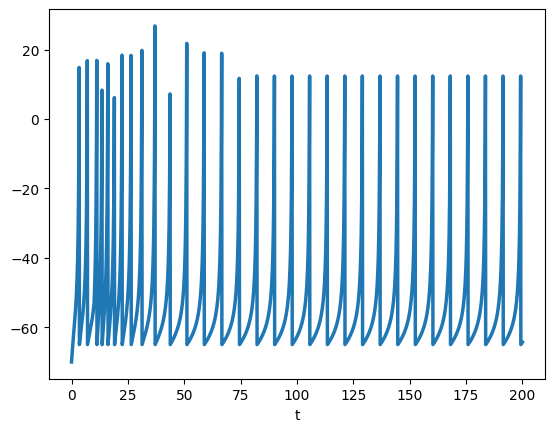

In [ ]:
# 3.2
plt.plot(t, w[0,:], linewidth=2.5)
plt.xlabel("t")
plt.show()

In [ ]:
# 3.3)
"""
vamos a intentar replicar los paneles del paper
"""

# definamos primero todas las i

def i_1(t):
  if t<25:
    i=0
  else:
    i=10
  return i

def i_2(t):
  if t<150:
    i=0
  else:
    i=2.5
  return i

def i_3(t):
  if t<100:
    i=-15
  else:
    i=0
  return i

def i_4(t):
  if t<10:
    i=0
  elif 10<=t<100:
    i=0.165
  elif 100<=t<105:
    i=10
  else:
    i=0.165
  return i

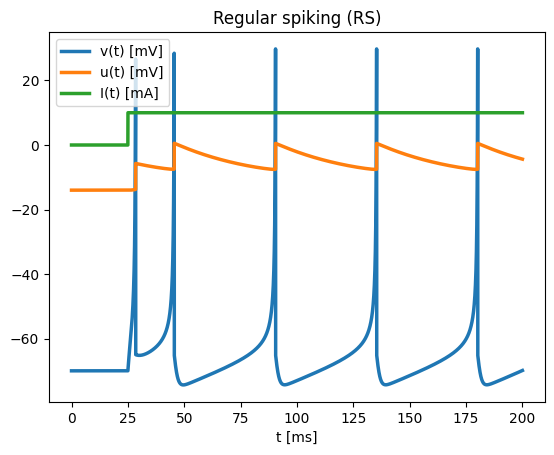

In [ ]:
# veamos ahora el primer caso

# el tiempo lo vamos a ir controlando nosotros
t_in = 0
t_fin = 200

# veamos primero los parámetros que no vamos a cambiar para el resto de las figuras
g=0.04
q=5
w=140
s=30

# ahora veamos los que sí cambiamos
a=0.02
b=0.2
c=-65
d=8

x_in=np.array([-70, b*(-70)]) # v(0), u(0)

p=np.array([g, q, w, i_1, a, b, c, d, s])

# vamos a cambiar h para ser más precisos
h=0.01
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

# grafiquemos tanto v como la corriente
corr_1 = [i_1(tiempo) for tiempo in t]

plt.plot(t, w[0,:], label='v(t) [mV]', linewidth=2.5)
plt.plot(t, w[1,:], label='u(t) [mV]', linewidth=2.5)
plt.plot(t, corr_1, label='I(t) [mA]', linewidth=2.5)
plt.xlabel("t [ms]")
#plt.ylabel("v(t)")
plt.title('Regular spiking (RS)')
plt.legend()
plt.show()

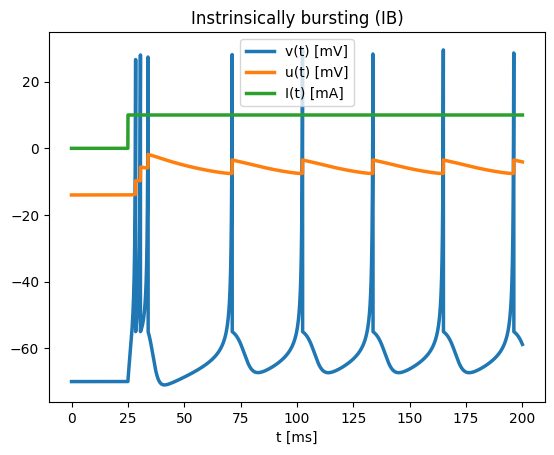

In [ ]:
# veamos ahora el segundo caso

# el tiempo lo vamos a ir controlando nosotros
t_in = 0
t_fin = 200

g=0.04
q=5
w=140
s=30

a=0.02
b=0.2
c=-55
d=4

x_in=np.array([-70, b*(-70)]) # v(0), u(0)

p=np.array([g, q, w, i_1, a, b, c, d, s])

# vamos a cambiar h para ser más precisos
h=0.01
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

# grafiquemos tanto v como la corriente
corr_1 = [i_1(tiempo) for tiempo in t]

plt.plot(t, w[0,:], label='v(t) [mV]', linewidth=2.5)
plt.plot(t, w[1,:], label='u(t) [mV]', linewidth=2.5)
plt.plot(t, corr_1, label='I(t) [mA]', linewidth=2.5)
plt.xlabel("t [ms]")
#plt.ylabel("v(t)")
plt.title('Instrinsically bursting (IB)')
plt.legend()
plt.show()

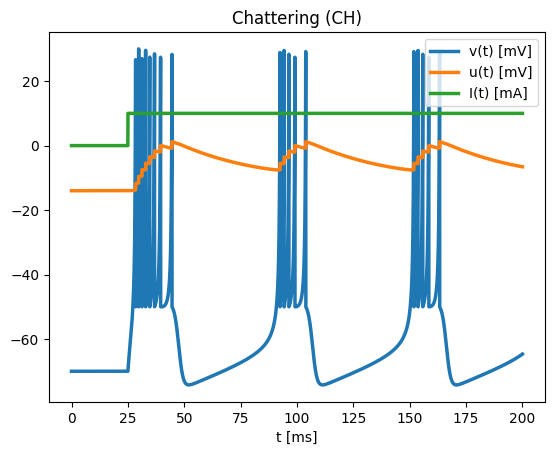

In [ ]:
# veamos ahora el tercer caso

# el tiempo lo vamos a ir controlando nosotros
t_in = 0
t_fin = 200

g=0.04
q=5
w=140
s=30

a=0.02
b=0.2
c=-50
d=2

x_in=np.array([-70, b*(-70)]) # v(0), u(0)

p=np.array([g, q, w, i_1, a, b, c, d, s])

# vamos a cambiar h para ser más precisos
h=0.01
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

# grafiquemos tanto v como la corriente
corr_1 = [i_1(tiempo) for tiempo in t]

plt.plot(t, w[0,:], label='v(t) [mV]', linewidth=2.5)
plt.plot(t, w[1,:], label='u(t) [mV]', linewidth=2.5)
plt.plot(t, corr_1, label='I(t) [mA]', linewidth=2.5)
plt.xlabel("t [ms]")
#plt.ylabel("v(t)")
plt.title('Chattering (CH)')
plt.legend()
plt.show()

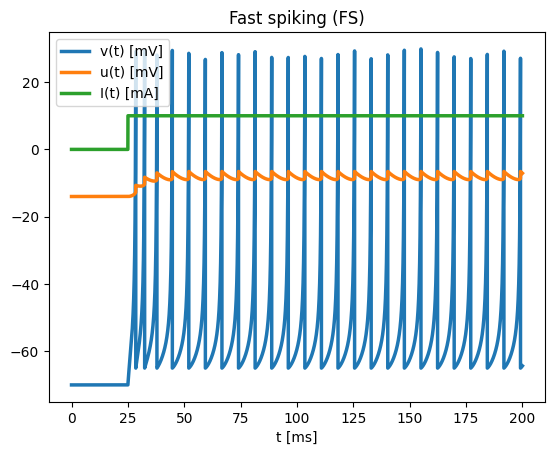

In [ ]:
# veamos ahora el cuarto caso

# el tiempo lo vamos a ir controlando nosotros
t_in = 0
t_fin = 200

g=0.04
q=5
w=140
s=30

a=0.1
b=0.2
c=-65
d=2

x_in=np.array([-70, b*(-70)]) # v(0), u(0)

p=np.array([g, q, w, i_1, a, b, c, d, s])

# vamos a cambiar h para ser más precisos
h=0.01
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

# grafiquemos tanto v como la corriente
corr_1 = [i_1(tiempo) for tiempo in t]

plt.plot(t, w[0,:], label='v(t) [mV]', linewidth=2.5)
plt.plot(t, w[1,:], label='u(t) [mV]', linewidth=2.5)
plt.plot(t, corr_1, label='I(t) [mA]', linewidth=2.5)
plt.xlabel("t [ms]")
#plt.ylabel("v(t)")
plt.title('Fast spiking (FS)')
plt.legend()
plt.show()

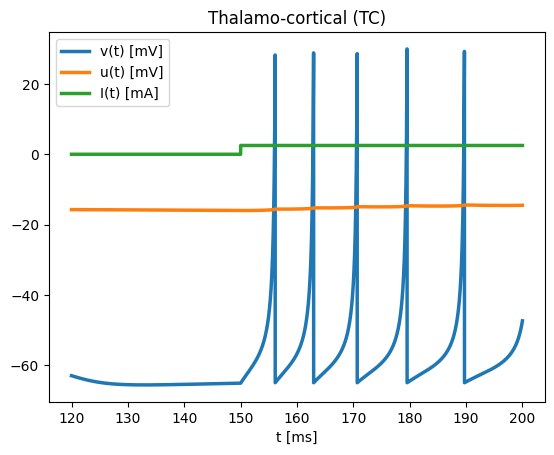

In [ ]:
# veamos ahora el quinto caso

# el tiempo lo vamos a ir controlando nosotros
t_in = 120
t_fin = 200

g=0.04
q=5
w=140
s=30

a=0.02
b=0.25
c=-65
d=0.05

x_in=np.array([-63, b*(-63)]) # v(0), u(0)

p=np.array([g, q, w, i_2, a, b, c, d, s])

# vamos a cambiar h para ser más precisos
h=0.01
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

# grafiquemos tanto v como la corriente
corr = [i_2(tiempo) for tiempo in t]

plt.plot(t, w[0,:], label='v(t) [mV]', linewidth=2.5)
plt.plot(t, w[1,:], label='u(t) [mV]', linewidth=2.5)
plt.plot(t, corr, label='I(t) [mA]', linewidth=2.5)
plt.xlabel("t [ms]")
#plt.ylabel("v(t)")
plt.title('Thalamo-cortical (TC)')
plt.legend()
plt.show()

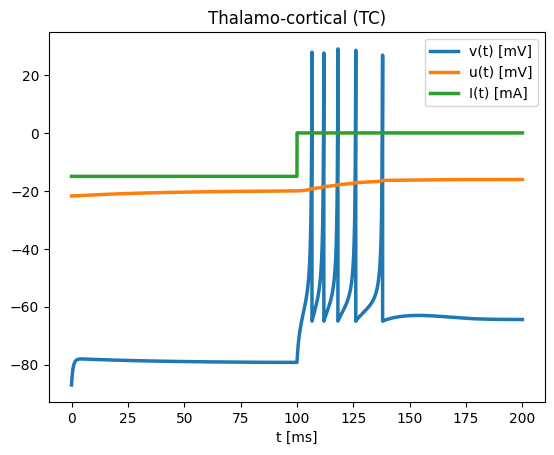

In [ ]:
# veamos ahora el sexto caso

# el tiempo lo vamos a ir controlando nosotros
t_in = 0
t_fin = 200

g=0.04
q=5
w=140
s=30

a=0.02
b=0.25
c=-65
d=0.05

x_in=np.array([-87, b*(-87)]) # v(0), u(0)

p=np.array([g, q, w, i_3, a, b, c, d, s])

# vamos a cambiar h para ser más precisos
h=0.01
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

# grafiquemos tanto v como la corriente
corr = [i_3(tiempo) for tiempo in t]

plt.plot(t, w[0,:], label='v(t) [mV]', linewidth=2.5)
plt.plot(t, w[1,:], label='u(t) [mV]', linewidth=2.5)
plt.plot(t, corr, label='I(t) [mA]', linewidth=2.5)
plt.xlabel("t [ms]")
#plt.ylabel("v(t)")
plt.title('Thalamo-cortical (TC)')
plt.legend()
plt.show()

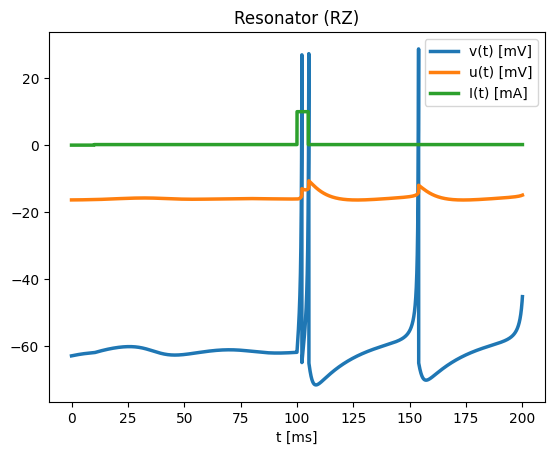

In [ ]:
# veamos ahora el septimo caso

# el tiempo lo vamos a ir controlando nosotros
t_in = 0
t_fin = 200

g=0.04
q=5
w=140
s=30

a=0.1
b=0.26
c=-65
d=2

x_in=np.array([-63, b*(-63)]) # v(0), u(0)

p=np.array([g, q, w, i_4, a, b, c, d, s])

# vamos a cambiar h para ser más precisos
h=0.01
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

# grafiquemos tanto v como la corriente
corr = [i_4(tiempo) for tiempo in t]

plt.plot(t, w[0,:], label='v(t) [mV]', linewidth=2.5)
plt.plot(t, w[1,:], label='u(t) [mV]', linewidth=2.5)
plt.plot(t, corr, label='I(t) [mA]', linewidth=2.5)
plt.xlabel("t [ms]")
#plt.ylabel("v(t)")
plt.title('Resonator (RZ)')
plt.legend()
plt.show()

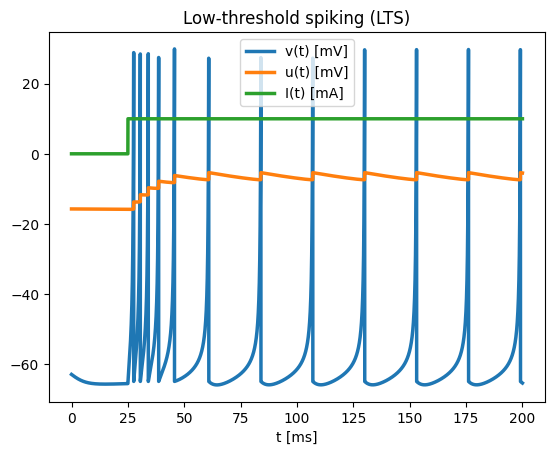

In [ ]:
# veamos el ultimo caso

# el tiempo lo vamos a ir controlando nosotros
t_in = 0
t_fin = 200

g=0.04
q=5
w=140
s=30

a=0.01
b=0.25
c=-65
d=2

x_in=np.array([-63, b*(-63)]) # v(0), u(0)

p=np.array([g, q, w, i_1, a, b, c, d, s])

# vamos a cambiar h para ser más precisos
h=0.01
k=int((t_fin-t_in)/h)

t, w = integrador_ode(rk4, f, x_in, t_in, t_fin, k, p, c=cond)

# grafiquemos tanto v como la corriente
corr = [i_1(tiempo) for tiempo in t]

plt.plot(t, w[0,:], label='v(t) [mV]', linewidth=2.5)
plt.plot(t, w[1,:], label='u(t) [mV]', linewidth=2.5)
plt.plot(t, corr, label='I(t) [mA]', linewidth=2.5)
plt.xlabel("t [ms]")
#plt.ylabel("v(t)")
plt.title('Low-threshold spiking (LTS)')
plt.legend()
plt.show()

## **Ejercicio 3)** Red de neuronas de Izhikevich

### El método de Euler-Maruyama

Nos interesa resolver una Ecuación Diferencial Estocástica (SDE) de la forma

$$dX_t = f(X_t,t)dt + g(X_t,t)dW_t\;\;\;\; (1)$$

donde, para cada $t\in \mathbb{R}$, $X_t,W_t$ son variables estocásticas con soporte en $\mathbb{R}$, y $f,g \in (\mathbb{R}^2\to \mathbb{R})$ son funciones.
Como función de $t$, asuminos que $W_t$ describe un proceso de Wiener. Es decir, asumimos que

1. $W_t$ una variable estocástica normalmente distribuida de valor esperado $\langle W_t \rangle = 0$ y varianza $\langle (W_t-\langle W_t\rangle)^2 \rangle = \langle W_t^2 \rangle = wt$ para algún $w\geq 0$, y

2. las variables estocásticas $W_{t+s}-W_s$ (caminatas futuras) y $W_s$ (caminatas pasadas) son estadísticamente independientes para todo $t\geq 0$ y $s\leq t$.

Nos interesa resolver la Ec. (1) en un intervalo $t\in [0,T]$ para una condición inicial $X_0=x_0$.

El método de Euler-Maruyama provee una aproximación $Y_t \approx X_t$ para $t\in \{0,\tau,2\tau,...,T\}$ donde $\tau=T/N$ para algún $N\gg 1$ fijo.
El método de Euler-Maruyama viene dado por la cadena de Markov

$$Y_{t+\tau} = Y_t + f(Y_t,t)\tau + g(Y_t,t)w\sqrt{\tau}\mathcal{N}\;\;\;\; (2)$$

donde $Y_0=x_0$ y $\mathcal{N}$ es una variable aleatoria normalmente distribuida de valor esperado 0 y varianza 1.

#### Caso multidimensional

El caso multidimensional es de la forma

$$dX_t = f(X_t,t)dt + g(X_t,t)dW_t\;\;\;\; (4)$$

donde $X_t,f(X_t,t) \in \mathbb{R}^d$, $g(X_t,t)\in \mathbb{R}^{d\times m}$ y $W_t\in \mathbb{R}^m$ para $d,m \in \mathbb{N}$.

En componentes

$$dX_{it} = f_i(X_t,t)dt + \sum_{j=1}^m g_{ij}(X_t,t)dW_{jt}\;\;\;\; (5)$$

Luego, la aproximación de Euler Maruyama toma la forma

$$Y_{i,t+\tau} = Y_{it} + f_i(Y_t,t)\tau + \sum_{j=1}^m g_{ij}(Y_t,t)w_j\sqrt{\tau}\mathcal{N}_j\;\;\;\; (6)$$

donde $\mathcal{N}_1,...,\mathcal{N}_m$ son variables aleatorias independientes, normalmente distribuidas, de valor esperado 0 y varianza 1.

### Red neuronal de neuronas de Izhikevich

El modelo de neurona de Izhikevich es una ODE, por lo que no hay estocasticidad.

Para simular una red, Izhikevich propone acoplar $n_e$ neuronas exitatorias y $n_i$ neuronas inhibitorias mediante una matriz de interacciones $s_{ij}$ con $i,j\in \{1,2,...,n\}$ para $n:=n_e+n_i$.
Más precisamente, propone

\begin{eqnarray}
\dot{v}_i(t) & = &  0.04v_i^2(t) + 5v_i(t) + 140 - u_i(t) + w_i(t) + \sum_{j=1}^n s_{ij} \Theta(v_j(t)) \;\;\;\; (7) \\
\dot{u}_i(t) & = &  a_i(b_iv_i(t)-u_i(t))
\end{eqnarray}

donde $w_i(t)$ representa el input externo afectando a la neurona $i$ y $\Theta$ es la función escalón de Heaviside.
Dicha funcion satisface $\Theta(x)=1$ si $x>0$ y $\Theta(x)=0$ en caso contrario, y es utilizada para normalizar la señal de disparo de las neuronas de entrada.

**Nota**: El input era anteriormente denotado por $I(t)$, pero hemos cambiado la notación a $w_i(t)$ para preservar letras mayúsculas a variables estocásticas e $i$ para indexar neuronas.

Luego, propone como input $w_i(t)$ una señal externa ruidosa que emule el input talámico.
Mas precisamente, propone elevar las variables $v_i(t)$, $u_i(t)$ y $w_i(t)$ a variables estocásticas $V_{it}$, $U_{it}$ y $W_{it}$ respectivamente.
De esta manera, la Ec. (7) adopta la forma

\begin{eqnarray}
dV_{it} & = &  \bigg(0.04V_{it}^2 + 5V_{it} + 140 - U_{it} + \sum_{j=1}^n s_{ij} \Theta(V_{it})\bigg)dt + dW_{it} \;\;\;\; (8) \\
dU_{it} & = &  a_i(b_iV_{it}-U_{it})dt
\end{eqnarray}

lo cual corresponde al sistema de SDEs de la Ec. (5) con:

1. $X_{it} = V_{it}$,

2. $X_{i+n,t} = U_{it}$,

3. $f_i(X_t,t) = 0.04X_{it}^2 + 5X_{it} + 140 - X_{i+n,t} + \sum_{j=1}^n s_{ij} X_{it}$,

4. $f_{i+n}(X_t,t) = a_i(b_iX_{it}-X_{i+n,t})$,

para todo $i=1,...,n$ y

5. $g_{rs}(X_t,t) = 1$ si $r=s\leq n$ y $g_{rs}(X_t,t) = 0$ en caso contrario.

### Refs.

* https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method
* https://ipython-books.github.io/134-simulating-a-stochastic-differential-equation/

* https://github.com/mattja/sdeint/blob/master/sdeint/integrate.py

* https://diffeq.sciml.ai/stable/tutorials/sde_example/

**1)** Adapte el código en Matlab del paper de Izhikevich a código en Python.

**2)** Acomode el código anterior a la teoría mencionada remplazando la función escalón $\Theta$ de Heavised por la función

$$
z(v)=\frac{87+v}{450}-0.0193
$$

**3)** Reproduzca la figura 3 del paper. Sugerencia, compartimentabilice el código en funciones, identificando las distintas componentes mencionadas en la teoría.

In [ ]:
# 3.1)
# MINUTO 20